# 5. Modeling Baseline

Build a simple, interpretable baseline model to predict hospital admission.
The goal is not to maximize performance, but to establish a reference point and expose model limitations.

## 5.0. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
neiss_2024_analysis = pd.read_csv('../clean_data/neiss_2024_analysis.csv')

neiss_2024_analysis.head(2).T


,0,1
cpsc_case_number,240108461,240108462
treatment_date,2024-01-01,2024-01-01
age_year,16.0,56.0
sex,male,female
race,unknown,white
hispanic,yes,no
body_part,shoulder,finger
diagnosis,"strain, sprain",laceration
location,place of recreation or sports,home
fire_involvement,no_fire_or_not_recorded,no_fire_or_not_recorded


## 5.1. Basic Feature Selection

Selected variables that showed strong association with admission in EDA and statistical analysis:

- These features represent demographic, injury, and contextual factors.

- No feature engineering is applied at this stage to keep the model interpretable.

In [ ]:
basic_features = [
    'age_group',
    'sex',
    'body_part',
    'diagnosis',
    'location',
    'fire_involvement'
]

## 5.2. Encoding

Convert categorical variables into numerical dummy variables.
- `drop_first=True` avoids redundancy in encoding.

In [ ]:
df_encoded = pd.get_dummies(neiss_2024_analysis[basic_features], drop_first=True)
X = df_encoded
y = neiss_2024_analysis['admitted']


## 5.3. Splitting the training data

Stratified sampling preserves the class distribution of admitted vs non-admitted cases.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 5.4. Baseline Model

Logistic regression is used as a baseline due to its interpretability and direct link to earlier statistical analysis.

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## 5.5. Prediction and Evaluation

Given class imbalance, evaluation focuses on:

- Recall for admitted cases (critical)
- ROC-AUC (ranking ability)
- Confusion matrix (error structure)

### 5.5.1 Predict and Metrics

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     63815
           1       0.61      0.24      0.34      8442

    accuracy                           0.89     72257
   macro avg       0.76      0.61      0.64     72257
weighted avg       0.87      0.89      0.87     72257

ROC-AUC: 0.8460


- The model performs well on the majority class but fails to capture admitted cases:
  - Only 24% of actual admissions are correctly identified
  - Around 76% of admitted patients are missed

- Despite high accuracy, performance is misleading due to class imbalance.

- ROC-AUC of 0.846 indicates the model can reasonably rank patients by risk, but this does not translate into effective classification. (Ranking ability ≠ decision quality)

### 5.5.2 Confusion Matrix

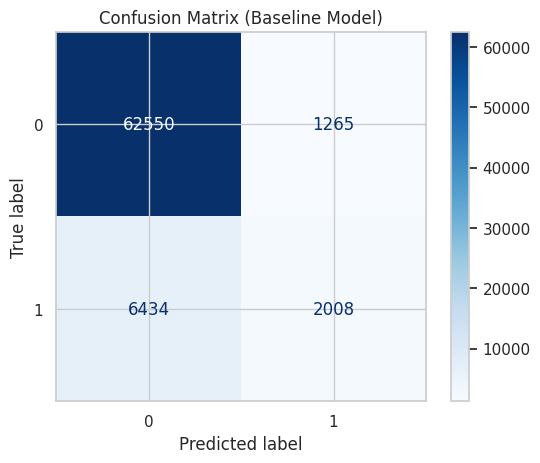

In [ ]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix (Baseline Model)")
plt.show()

- The model is heavily biased toward predicting non-admission,
resulting in a large number of false negatives.

### 5.6. Class Imbalance Check

In [ ]:
y.value_counts(normalize=True)


,proportion
admitted,
0,0.883161
1,0.116839


- The dataset is highly imbalanced, with admitted cases representing a small minority.
- This explains the model’s tendency to favor the majority class.

## 5.7. Model Interpretation

In [ ]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

coef_df.head(10)


,feature,coefficient
46,"diagnosis_dermatitis, conjunctivitis",-2.871383
60,"diagnosis_strain, sprain",-2.706798
48,diagnosis_electric shock,-1.835309
1,age_group_elderly (65+),1.813503
33,diagnosis_anoxia,-1.762710
8,body_part_all parts body,1.645779
14,body_part_finger,-1.641714
27,body_part_toe,-1.577892
32,body_part_wrist,-1.421766
30,body_part_upper leg,1.396701


- The model is heavily driven by specific diagnosis categories.  Several diagnoses (e.g., dermatitis, strain/sprain) have large negative coefficients, indicating that the model strongly associates them with non-admission.

- This suggests the model has learned shortcut patterns: Certain diagnoses are treated as “almost never admitted”

- While this improves overall accuracy, it creates a critical issue: The model becomes overconfident and fails to recognize exceptions.


## 5.8. Error Analysis

In [ ]:
df_test = X_test.copy()
df_test['actual'] = y_test
df_test['pred'] = y_pred
df_test['prob'] = y_prob
df_test.head(2)

,age_group_child (5-12),age_group_elderly (65+),age_group_infant (<1),age_group_mid adult (35-49),age_group_older adult (50-64),age_group_toddler (1-4),age_group_young adult (18-34),sex_male,body_part_all parts body,body_part_ankle,...,location_place of recreation or sports,location_school/daycare,location_street or highway,location_unknown,fire_involvement_fire_fd_not_attended,fire_involvement_fire_fd_unknown,fire_involvement_no_fire_or_not_recorded,actual,pred,prob
115639,True,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,True,0,0,0.003098
260449,False,False,False,False,True,False,False,True,False,False,...,False,False,False,True,False,False,True,0,0,0.017196


In [ ]:
false_negatives = df_test[(df_test['actual'] == 1) & (df_test['pred'] == 0)]
fn_features = false_negatives.drop(columns=['actual','pred','prob']).mean().sort_values(ascending=False)
fn_features.head(10)


,0
fire_involvement_no_fire_or_not_recorded,0.987877
sex_male,0.540099
location_home,0.439229
age_group_elderly (65+),0.429282
location_unknown,0.323438
body_part_head,0.272303
diagnosis_other/not stated,0.268729
diagnosis_internal organ injury,0.229873
diagnosis_fracture,0.213864
age_group_older adult (50-64),0.182157


- False negatives (missed admissions) reveal many missed cases still fall into “low-risk” categories such as:
  - No fire involvement
  - Home incidents

- This indicates that the model is not failing randomly. Instead, it is systematically biased:
  - It relies too heavily on dominant patterns (e.g., diagnosis).
  - And fails to capture less obvious but high-risk situations.
- The model overfits to “typical” cases and fails on atypical but critical ones.


## 5.9. Overall

- The baseline model shows a structural limitation.

- It achieves strong overall performance (ROC-AUC = 0.846), but relies heavily on dominant patterns (e.g., diagnosis).
- As a result, it performs well on typical cases but misses atypical admissions.
- This creates a key gap: the model is accurate on average but unreliable in edge cases.
- This highlights an important insight: statistical association does not guarantee predictive usefulness, especially under class imbalance.


## 5.10 Next Steps
- Address class imbalance: class weighting or resampling

- Improve feature representation: incorporate injury severity and contextual signals